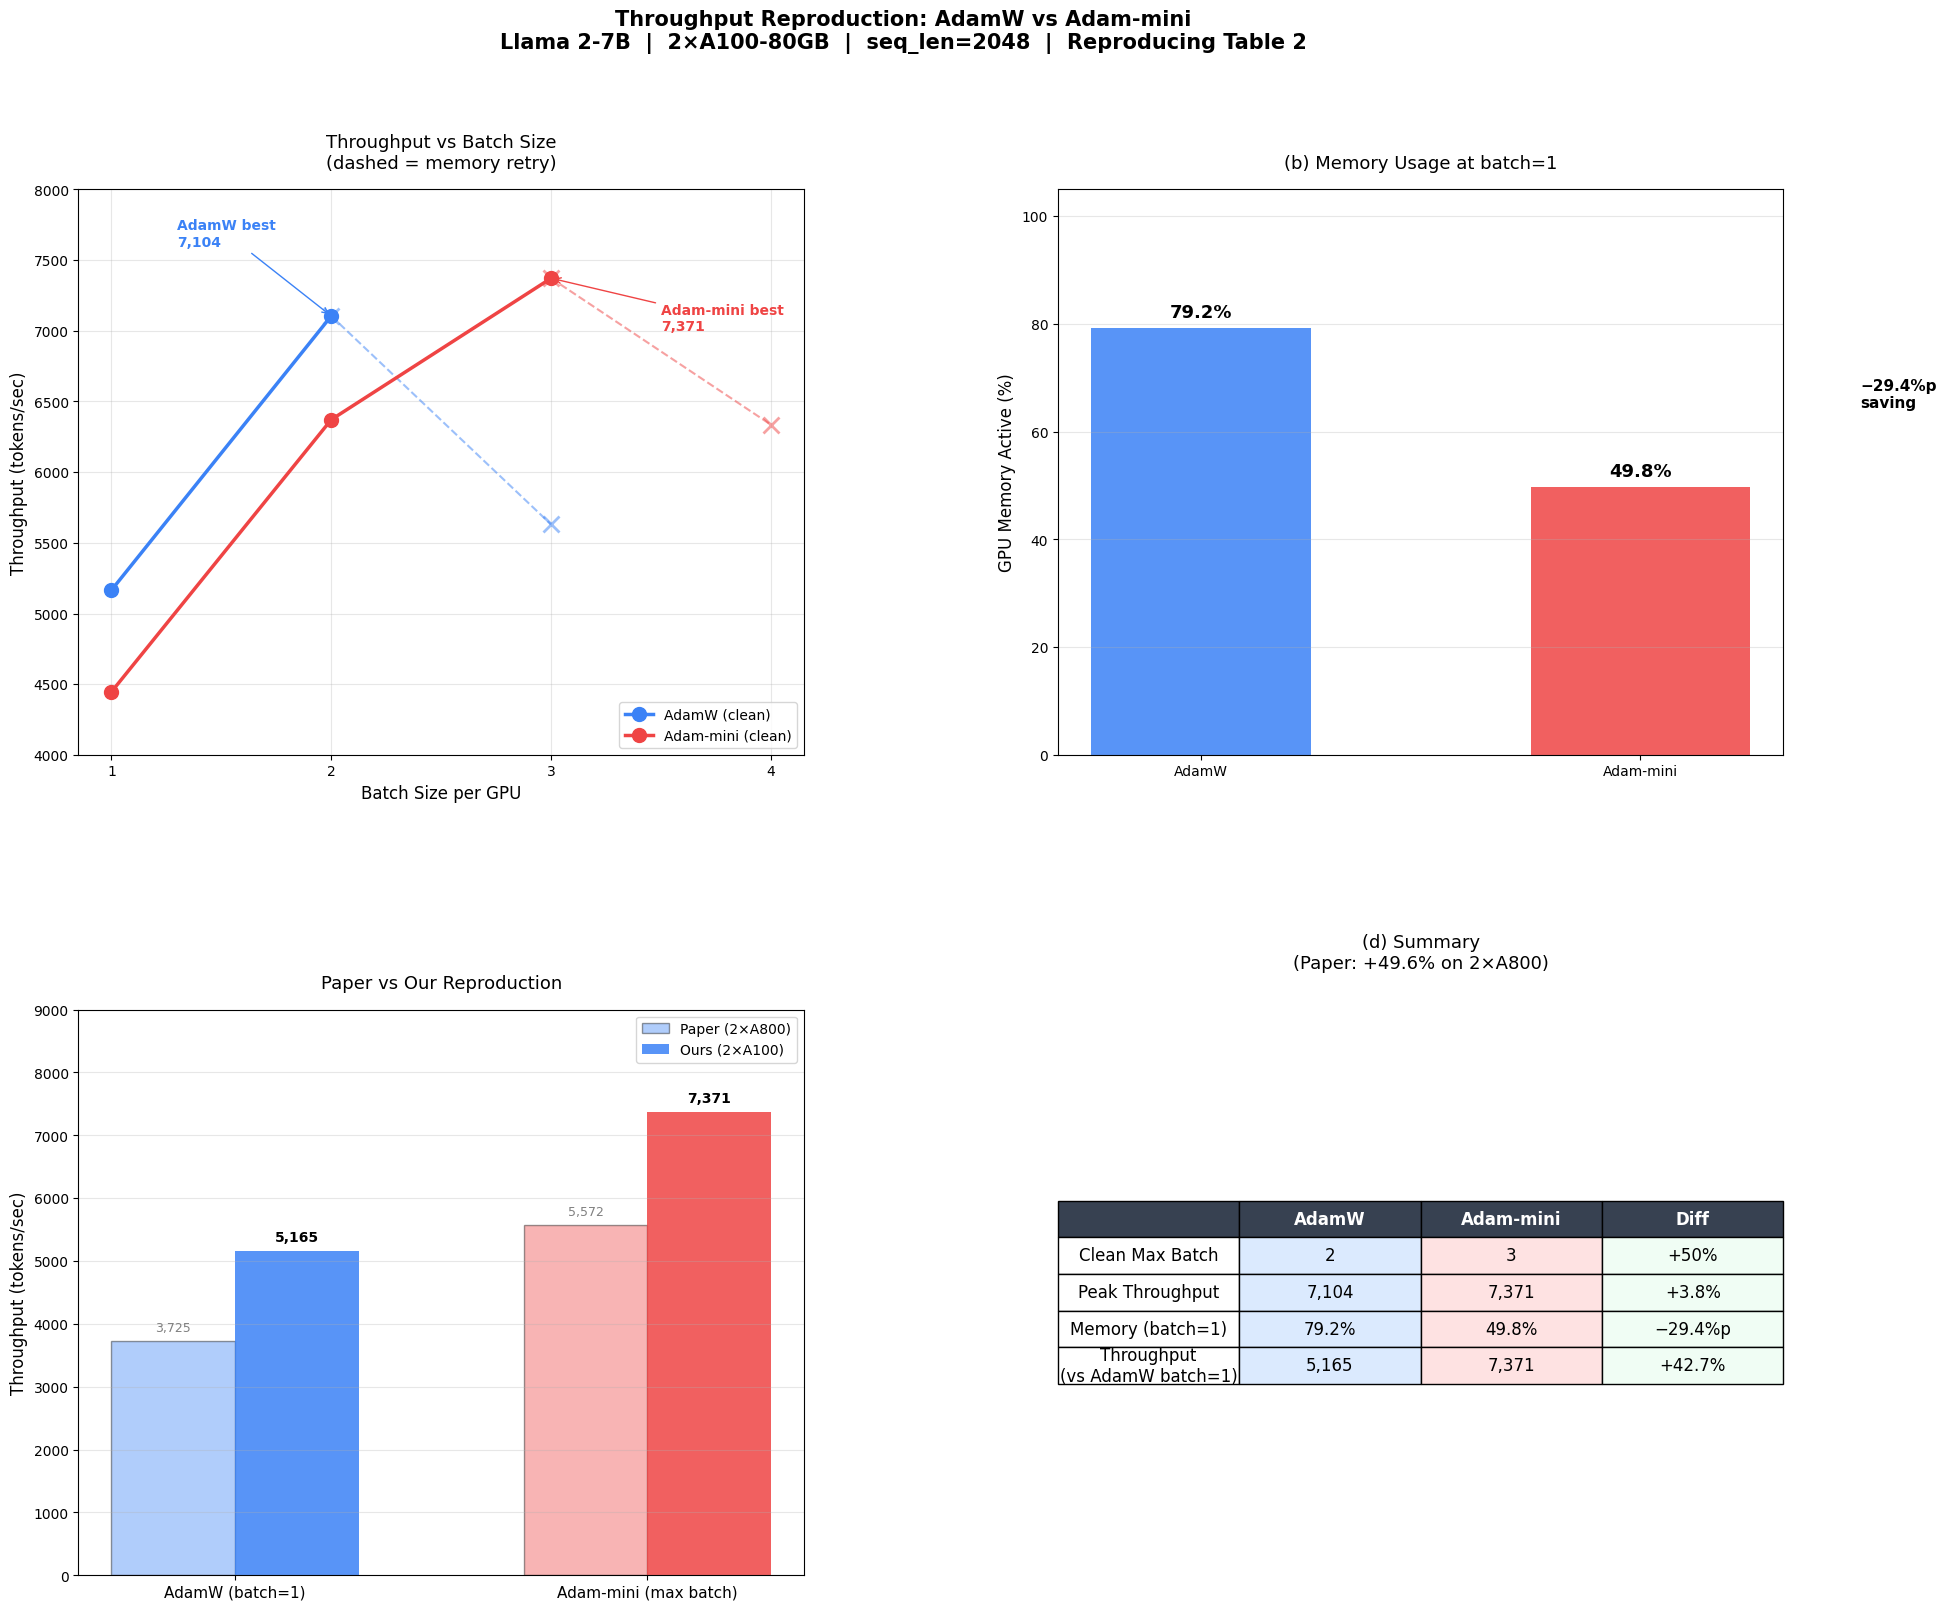

In [4]:
import matplotlib.pyplot as plt
import numpy as np

BLUE = '#3b82f6'
RED = '#ef4444'

fig = plt.figure(figsize=(22, 18))
plt.subplots_adjust(hspace=0.45, wspace=0.35)

# ===== (a) Throughput vs Batch Size =====
ax = fig.add_subplot(2, 2, 1)

ax.plot([1, 2], [5165, 7104], '-o', color=BLUE, linewidth=2.5,
        markersize=10, label='AdamW (clean)', zorder=5)
ax.plot([1, 2, 3], [4446, 6371, 7371], '-o', color=RED, linewidth=2.5,
        markersize=10, label='Adam-mini (clean)', zorder=5)
ax.plot([2, 3], [7104, 5630], '--x', color=BLUE, linewidth=1.5,
        markersize=12, alpha=0.5, markeredgewidth=2)
ax.plot([3, 4], [7371, 6335], '--x', color=RED, linewidth=1.5,
        markersize=12, alpha=0.5, markeredgewidth=2)

ax.annotate('AdamW best\n7,104', xy=(2, 7104),
            xytext=(1.3, 7600), fontsize=10, fontweight='bold', color=BLUE,
            arrowprops=dict(arrowstyle='->', color=BLUE))
ax.annotate('Adam-mini best\n7,371', xy=(3, 7371),
            xytext=(3.5, 7000), fontsize=10, fontweight='bold', color=RED,
            arrowprops=dict(arrowstyle='->', color=RED))

ax.set_xlabel('Batch Size per GPU', fontsize=12)
ax.set_ylabel('Throughput (tokens/sec)', fontsize=12)
ax.set_title('Throughput vs Batch Size\n(dashed = memory retry)', fontsize=13, pad=15)
ax.legend(fontsize=10, loc='lower right')
ax.set_xticks([1, 2, 3, 4])
ax.set_ylim(4000, 8000)
ax.grid(True, alpha=0.3)

# ===== (b) Memory Usage =====
ax = fig.add_subplot(2, 2, 2)

bars = ax.bar(['AdamW', 'Adam-mini'], [79.2, 49.8],
              color=[BLUE, RED], alpha=0.85, width=0.5)

ax.annotate('', xy=(1.35, 79.2), xytext=(1.35, 49.8),
            arrowprops=dict(arrowstyle='<->', color='black', lw=2))
ax.text(1.5, 64.5, '−29.4%p\nsaving', fontsize=11, fontweight='bold')

for bar, val in zip(bars, [79.2, 49.8]):
    ax.text(bar.get_x() + bar.get_width()/2, val + 2,
            f'{val}%', ha='center', fontsize=13, fontweight='bold')

ax.set_ylabel('GPU Memory Active (%)', fontsize=12)
ax.set_title('(b) Memory Usage at batch=1', fontsize=13, pad=15)
ax.set_ylim(0, 105)
ax.grid(True, alpha=0.3, axis='y')

# ===== (c) Paper vs Ours =====
ax = fig.add_subplot(2, 2, 3)

x = np.arange(2)
width = 0.3

bars1 = ax.bar(x - width/2, [3725, 5572], width,
               label='Paper (2×A800)', color=[BLUE, RED], alpha=0.4, edgecolor='black')
bars2 = ax.bar(x + width/2, [5165, 7371], width,
               label='Ours (2×A100)', color=[BLUE, RED], alpha=0.85)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 150,
            f'{int(bar.get_height()):,}', ha='center', fontsize=9, color='gray')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 150,
            f'{int(bar.get_height()):,}', ha='center', fontsize=10, fontweight='bold')


ax.set_xticks(x)
ax.set_xticklabels(['AdamW (batch=1)', 'Adam-mini (max batch)'], fontsize=11)
ax.set_ylabel('Throughput (tokens/sec)', fontsize=12)
ax.set_title('Paper vs Our Reproduction', fontsize=13, pad=15)
ax.legend(fontsize=10)
ax.set_ylim(0, 9000)
ax.grid(True, alpha=0.3, axis='y')

# ===== (d) Summary Table =====
ax = fig.add_subplot(2, 2, 4)
ax.axis('off')

table_data = [
    ['', 'AdamW', 'Adam-mini', 'Diff'],
    ['Clean Max Batch', '2', '3', '+50%'],
    ['Peak Throughput', '7,104', '7,371', '+3.8%'],
    ['Memory (batch=1)', '79.2%', '49.8%', '−29.4%p'],
    ['Throughput\n(vs AdamW batch=1)', '5,165', '7,371', '+42.7%'],
]

table = ax.table(cellText=table_data, loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.0, 2.2)

for j in range(4):
    table[0, j].set_facecolor('#374151')
    table[0, j].set_text_props(color='white', fontweight='bold')
for i in range(1, 5):
    table[i, 1].set_facecolor('#dbeafe')
    table[i, 2].set_facecolor('#fee2e2')
    table[i, 3].set_facecolor('#f0fdf4')

ax.set_title('(d) Summary\n(Paper: +49.6% on 2×A800)', fontsize=13, pad=30)

fig.suptitle(
    'Throughput Reproduction: AdamW vs Adam-mini\n'
    'Llama 2-7B  |  2×A100-80GB  |  seq_len=2048  |  Reproducing Table 2',
    fontsize=15, fontweight='bold', y=0.98
)

plt.savefig('throughput_results.png', dpi=150, bbox_inches='tight')
plt.show()